# Notebook 03 — Joined Table and Exploration

I bring the prepared HLE and contextual measures together for **660 MSOA21 areas**. One row will be one area. I add the average of male and female HLE as the headline outcome, keep the male and female figures with their confidence limits and imputation flags for a final check, and explore which contextual measures are linked with HLE.

This is descriptive, exploratory analysis. I do not run a hypothesis test or fit a model here. I use the outputs of Notebook 02 as they are and do not change them.

Sources and definitions follow [Notebook 01](../A%20%E2%80%94%20Source%20Exploration/01_Source_Exploration.ipynb) and [Notebook 02](../B%20%E2%80%94%20Data%20Preparation/02_Data_Preparation.ipynb). HLE covers 2019–2023; Census measures are from 2021, income is year ending March 2023, and pollution, fuel poverty and crime are 2024 context.

### Results at a glance

The checks retain **660 areas**, **55 columns** and **32 contextual measures**. All joins are one-to-one. The only missing cells are the six deliberately blanked crime values. Median HLE is **64.1 years** on average, **63.5 years** for men and **64.8 years** for women. The strongest observed links and provisional theme choices are shown below; they are not causal findings or a final predictor set.

### Working assumptions

- All 660 areas remain. Student flags are caveats, not reasons to remove an area.
- Only the recorded-crime analysis column is blanked for visitor hubs. Published crime and ASB columns stay untouched.
- I use the saved flags as they are. I do not change or refit the **greater-than-50% student rule** or the **Q3 + 3 × IQR crime fence**.
- I keep the ethnicity shares and explore them separately. I decide later how, or whether, they enter any modelling.
- I match every merge on the same codes, one-to-one. No averaging of deprivation ranks or deciles is involved.

## 1. Environment and project files

I use the project virtual environment when I run this notebook from my working copy. In a GitHub clone, I create a virtual environment and install the packages in `requirements.txt`. The notebook finds either the working copy’s `Data` folder or the repository’s `data` folder relative to the notebook. Each run refreshes its saved tables and charts in the cleaned `Wide` output folder.

In [1]:
from pathlib import Path
import sys, json
import numpy as np
import pandas as pd
import scipy
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display
%matplotlib inline


# Find the project from the notebook's current folder in either the working copy or GitHub layout.
project_folder = next(p for p in [Path.cwd(), *Path.cwd().parents]
                      if any((p / candidate).is_dir()
                             for candidate in ("Data/Cleaned/HLE", "data/cleaned/HLE")))

# Enforce the project environment in the working copy. A GitHub clone has no bundled .venv.
expected_environment = project_folder / "VS_CODE/.venv"
if expected_environment.is_dir():
    assert Path(sys.prefix).resolve() == expected_environment.resolve(), "Select the project virtual environment."


data_folder = project_folder / ("Data" if (project_folder / "Data").is_dir() else "data")
cleaned_folder = data_folder / ("Cleaned" if (data_folder / "Cleaned").is_dir() else "cleaned")
output_folder = cleaned_folder / "Wide"
figure_folder = output_folder / "figures"
figure_folder.mkdir(parents=True, exist_ok=True)

# Clear the previous run's files so nothing stale survives if an output is renamed or dropped.
for old_file in [*output_folder.glob("*"), *figure_folder.glob("*")]:
    if old_file.is_file():
        old_file.unlink()


# One plotting style for every figure in this notebook.
sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 150, "axes.spines.top": False, "axes.spines.right": False})


def read_csv(relative):
    parts = Path(relative).parts
    if parts and parts[0].casefold() == "cleaned":
        parts = (cleaned_folder.name, *parts[1:])
    path = data_folder.joinpath(*parts)
    return pd.read_csv(path)


# Every table is written through this helper, so encoding and line endings are the same everywhere.
def save_csv(table, filename, index=False):
    with (output_folder / filename).open("w", encoding="utf-8", newline="") as stream:
        table.to_csv(stream, index=index)


# Save, then show, then close, so figures reach the folder and do not pile up in memory.
def save_figure(figure, filename):
    destination = figure_folder / filename
    figure.savefig(destination, bbox_inches="tight")
    plt.show()
    plt.close(figure)


print(f"Python {sys.version.split()[0]} | pandas {pd.__version__} | scipy {scipy.__version__} | seaborn {sns.__version__}")
print("Output folder:", output_folder.relative_to(project_folder).as_posix())


Python 3.14.7 | pandas 3.0.6 | scipy 1.18.1 | seaborn 0.13.2
Output folder: data/cleaned/Wide


## 2. HLE: preserve estimates and uncertainty

I use the **supporting HLE table** saved by Notebook 02, because the compact table omits the confidence limits and imputation fields. I check the area/sex key and interval order before pivoting. Both original imputation fields survive as integers: `LE imputed` counts affected age groups (including one source value of 2), and the health-prevalence field records its source indicator. The additional boolean `imputed` flag means either source field is greater than zero. Nine male estimates are flagged; no female estimates are flagged. I also check the point estimates and familiar names against the saved compact HLE table.

### Why I use an average of male and female HLE

Male and female HLE track each other closely across the 660 areas (correlation 0.97, Notebook 01), so analysing them separately would mostly repeat the same result twice and add precision that is not really there. I take `hle_average = (male + female) / 2` as the headline outcome and keep the male and female columns for a final check that the average is not hiding a difference between the sexes. The average is my own derived measure, not an ONS statistic.

I get an approximate interval for it from the two published intervals. Each 95% interval gives a standard error, (UCI − LCI) / (2 × 1.96), and I combine them as √(SE_male² + SE_female²) / 2. That assumes the male and female errors are independent. They probably are not quite, because both come from the same area and period, so the interval for the average is likely a little too narrow. I treat it as a guide, not a precise figure.

In [2]:
# The support file keeps the confidence limits and imputation flags that the compact file drops.
hle_source_path = "Cleaned/HLE/hle_2019_2023_msoa_support.csv"
hle = read_csv(hle_source_path)
compact_hle = read_csv("Cleaned/HLE/hle_2019_2023_msoa.csv")

# Structure checks before anything is reshaped: two sexes, one period, one row per area and sex, 660 areas.
assert set(hle["Sex"]) == {"Male", "Female"}
assert hle["Period"].eq("2019 to 2023").all()
assert hle["Area type"].eq("MSOA").all()
assert not hle.duplicated(["Area code", "Sex"]).any()
assert len(hle) == 1320 and hle["Area code"].nunique() == 660
assert hle.groupby("Area code")["Sex"].nunique().eq(2).all()
assert hle[["HLE", "LCI", "UCI", "LE imputed", "Health prevalence imputed"]].notna().all().all()

# The limits must bracket the estimate.
assert hle["LCI"].le(hle["HLE"]).all() and hle["HLE"].le(hle["UCI"]).all()

# The imputation flags are counts or indicators, so they must be whole numbers of zero or more.
for flag in ["LE imputed", "Health prevalence imputed"]:
    assert pd.api.types.is_integer_dtype(hle[flag]) and hle[flag].ge(0).all()

assert not compact_hle.duplicated(["area_code", "sex"]).any()

# Cross-check the support file against the compact file used earlier: the same estimate for every area and sex.
point_check = compact_hle.merge(hle[["Area code", "Sex", "HLE"]],
    left_on=["area_code", "sex"], right_on=["Area code", "Sex"], validate="one_to_one", how="outer", indicator=True)

assert point_check["_merge"].eq("both").all()
assert np.allclose(point_check["hle_years"], point_check["HLE"], rtol=0, atol=1e-10)
assert compact_hle.groupby("area_code")["local_area_name"].nunique().eq(1).all()

# One row per area. The two sexes become columns below.
wide = compact_hle[["area_code", "local_area_name"]].drop_duplicates().sort_values("area_code").reset_index(drop=True)
area_codes = set(wide["area_code"])

# Record the row count after every merge, so the joins can be audited afterwards.
join_audit = []
source_for_column = {"area_code": "MSOA21 area code", "local_area_name": "Cleaned/HLE/hle_2019_2023_msoa.csv"}

# Pivot long to wide, one sex at a time. The estimate, limits and flags get a prefix (hle_male_, hle_female_).
for sex in ["Male", "Female"]:
    prefix = "hle_" + sex.lower()
    columns = {"Area code":"area_code", "HLE":prefix, "LCI":prefix+"_lci", "UCI":prefix+"_uci",
               "LE imputed":prefix+"_le_imputed", "Health prevalence imputed":prefix+"_health_prevalence_imputed"}
    part = hle.loc[hle["Sex"].eq(sex), list(columns)].rename(columns=columns)

    # True when either source imputation field is above zero.
    part[prefix+"_imputed"] = part[[prefix+"_le_imputed", prefix+"_health_prevalence_imputed"]].gt(0).any(axis=1)

    # validate="one_to_one" makes pandas fail if a code repeats, instead of silently multiplying rows.
    wide = wide.merge(part, on="area_code", how="left", validate="one_to_one")
    assert len(wide) == 660 and wide["area_code"].is_unique
    join_audit.append({"Input": "HLE " + sex, "Rows after merge":len(wide), "Unmatched codes":0})
    source_for_column.update({c: hle_source_path for c in part if c != "area_code"})

# Standard error of each sex from its published 95% interval: full width divided by 2 × 1.96.
se_male = (wide["hle_male_uci"] - wide["hle_male_lci"]) / (2 * 1.96)
se_female = (wide["hle_female_uci"] - wide["hle_female_lci"]) / (2 * 1.96)

# The headline outcome: the mean of the two sexes. It is derived here, not published by ONS.
wide["hle_average"] = (wide["hle_male"] + wide["hle_female"]) / 2
se_average = np.sqrt(se_male**2 + se_female**2) / 2  # assumes the two sexes' errors are independent
wide["hle_average_lci"] = wide["hle_average"] - 1.96 * se_average
wide["hle_average_uci"] = wide["hle_average"] + 1.96 * se_average
assert wide["hle_average_lci"].lt(wide["hle_average"]).all() and wide["hle_average"].lt(wide["hle_average_uci"]).all()
source_for_column.update({c: "Derived in this notebook from the male and female HLE columns" for c in ["hle_average","hle_average_lci","hle_average_uci"]})
wide["hle_period"] = "2019–2023"
source_for_column["hle_period"] = hle_source_path

# Interval widths show how uncertain each estimate is. The average's is derived, so it is likely too narrow.
interval_widths = pd.DataFrame({sex: wide["hle_"+sex.lower()+"_uci"] - wide["hle_"+sex.lower()+"_lci"] for sex in ["Male","Female"]})
interval_widths["Average"] = wide["hle_average_uci"] - wide["hle_average_lci"]
interval_summary = interval_widths.agg(["median","min","max"]).T.rename_axis("Sex")

display(interval_summary.round(2))
print("HLE values match the compact input; estimates, intervals and both source flags retained.")

,median,min,max
Sex,,,
Male,3.00,2.10,5.80
Female,2.80,1.80,8.80
Average,2.06,1.42,5.16


HLE values match the compact input; estimates, intervals and both source flags retained.


## 3. Join the compact measure files

I merge the ten compact contextual files, not their counts, coverage-check or support files. Every input must have the same 660 unique codes and matching area names. I drop the repeated name column before merging, use `validate="one_to_one"`, and assert 660 rows after **every** merge. Ethnicity retains its 19 original shares; no grouping choice is made here.

In [3]:
# One entry per input file: its theme, the file, and for each column a label, unit, period and definition. These feed the data dictionary.
measure_specs = [('Household deprivation', 'Household Deprivation/household_deprivation_2021_msoa.csv', {'households_deprived_2plus_pct': ('Households deprived in ≥2 dimensions', '% households', '2021', 'Households deprived in two or more Census dimensions / all households × 100; health/disability overlaps HLE.')}), ('Overcrowding', 'Overcrowding/overcrowding_2021_msoa.csv', {'overcrowded_households_pct': ('Overcrowded households', '% households', '2021', 'Households with bedroom occupancy rating -1 or -2 / all households × 100.')}), ('Fuel poverty', 'Fuel Poverty/fuel_poverty_2024_msoa.csv', {'fuel_poor_households_pct': ('Fuel-poor households', '% households', '2024', 'LSOA fuel-poor household counts summed to MSOA / summed households × 100.')}), ('NO₂', 'Pollution/no2_2024_msoa.csv', {'no2_area_mean_ug_m3': ('NO₂ area mean', 'µg/m³', '2024', 'Area-weighted modelled grid concentration; not population-weighted exposure.')}), ('PM2.5', 'Pollution/pm25_2024_msoa.csv', {'pm25_area_mean_ug_m3': ('PM2.5 area mean', 'µg/m³', '2024', 'Area-weighted modelled grid concentration; not population-weighted exposure.')}), ('Economic activity', 'Economic Activity/economic_activity_2021_msoa.csv', {'employed_residents_16plus_pct': ('Employed residents aged 16+', '% residents aged 16+', '2021', 'Includes full-time students consistently in employment numerator and resident denominator.'), 'unemployment_rate_active_pct': ('Unemployment rate', '% economically active residents', '2021', 'Unemployed / economically active residents × 100; includes full-time student activity.')}), ('Qualifications', 'Qualifications/qualifications_2021_msoa.csv', {'no_qualifications_pct': ('No qualifications', '% residents aged 16+', '2021', 'No qualifications / residents aged 16+ × 100.'), 'level2_qualifications_pct': ('Level 2 qualifications', '% residents aged 16+', '2021', 'Highest qualification Level 2 / residents aged 16+ × 100.'), 'level4plus_pct': ('Level 4+ qualifications', '% residents aged 16+', '2021', 'Highest qualification Level 4 or above / residents aged 16+ × 100.')}), ('Income', 'Income/income_after_housing_costs_fye2023_msoa.csv', {'annual_equivalised_income_after_housing_costs_gbp': ('Household income after housing costs', '£ per year', 'FYE March 2023', 'ONS modelled annual equivalised disposable household income after housing costs.')}), ('Ethnicity', 'Ethnicity/ethnicity_2021_msoa.csv', {}), ('Crime', 'Crime/crime_2024_msoa_provisional.csv', {'recorded_crime_rows_per_1000_residents': ('Published recorded-crime rate', 'published rows / 1,000 residents', '2024 / population 2021', 'Published recorded-crime rows, excluding ASB, divided by Census 2021 residents; repeated-ID ambiguity remains.'), 'asb_rows_per_1000_residents': ('Anti-social behaviour rate', 'published rows / 1,000 residents', '2024 / population 2021', 'ASB rows are separate from recorded crime. Resident denominator can be distorted by visitor footfall; unchanged here.')})]

# The 19 ethnic-group definitions are built in the loop from this feature dictionary, not typed out.
ethnicity_dictionary = read_csv("Cleaned/Ethnicity/ethnicity_2021_feature_dictionary.csv")
feature_info = {}
measure_columns = []
ethnicity_columns = []

# Merge one input at a time, checking it before it joins.
for theme, relative, definitions in measure_specs:
    frame = read_csv("Cleaned/" + relative)

    # Each input must cover exactly the same 660 areas as the HLE table.
    assert len(frame) == 660 and frame["area_code"].is_unique, theme
    assert set(frame["area_code"]) == area_codes, theme

    # The familiar name must agree between the main table and each input.
    name_check = wide[["area_code", "local_area_name"]].merge(frame[["area_code", "local_area_name"]],
                         on="area_code", validate="one_to_one", suffixes=("_main", "_input"))
    assert name_check["local_area_name_main"].eq(name_check["local_area_name_input"]).all(), theme
    features = [c for c in frame if c not in ["area_code", "local_area_name"]]

    # A column that already exists would get an _x or _y suffix from merge, so stop here instead.
    assert not set(features).intersection(wide.columns), "A repeated feature needs review."

    # The 19 ethnic-group shares must add up to 100% in every area.
    if theme == "Ethnicity":
        ethnicity_columns = features
        assert len(features) == 19
        assert np.allclose(frame[features].sum(axis=1),100,atol=1e-8)
        for feature in features:
            row = ethnicity_dictionary.set_index("feature").loc[feature]
            label = feature.removesuffix("_pct").replace("_", " ").capitalize()
            definitions[feature] = (label, "% all usual residents", "2021", str(row["source_field"]) + " / all usual residents × 100.")

    # Every column needs a definition and every definition a column.
    assert set(features) == set(definitions), theme

    for feature in features:
        assert pd.api.types.is_numeric_dtype(frame[feature]) and frame[feature].notna().all(), feature
        assert np.isfinite(frame[feature]).all(), feature
        label,unit,period,definition = definitions[feature]
        feature_info[feature] = {"label":label,"unit":unit,"period":period,"definition":definition,"theme":theme}
        source_for_column[feature] = "Cleaned/" + relative

    # Drop the repeated name column. The merge key is the area code.
    wide = wide.merge(frame.drop(columns="local_area_name"), on="area_code", how="left", validate="one_to_one")
    assert len(wide) == 660 and wide["area_code"].is_unique
    measure_columns.extend(features)
    join_audit.append({"Input":theme,"Rows after merge":len(wide),"Unmatched codes":0})

display(pd.DataFrame(join_audit))

,Input,Rows after merge,Unmatched codes
0,HLE Male,660,0
1,HLE Female,660,0
2,Household deprivation,660,0
3,Overcrowding,660,0
4,Fuel poverty,660,0
5,NO₂,660,0
6,PM2.5,660,0
7,Economic activity,660,0
8,Qualifications,660,0
9,Income,660,0


## 4. Apply saved flags without dropping areas

The flags file repeats the crime rate. I bring in **only the area code and four boolean flags**, so there is no duplicate crime field. I use the existing visitor-hub flag to blank `crime_for_analysis` for six areas. The original crime rate remains unchanged, student areas remain in the table, and all other measures remain intact. Two areas have both flags, so their crime value is blank because they are visitor hubs, not because they are student areas.

In [4]:
# The flags were fitted in Notebook 02. They are read here and not refitted.
flags_source = read_csv("Cleaned/Modelling Flags/modelling_flags_msoa.csv")
flag_columns = ["student_dominated","visitor_hub","exclude_from_crime_analysis","city_centre_caveat"]
assert flags_source["area_code"].is_unique and set(flags_source["area_code"]) == area_codes

for column in flag_columns:
    assert pd.api.types.is_bool_dtype(flags_source[column]) and flags_source[column].notna().all()

assert flags_source["student_dominated"].sum() == 6 and flags_source["visitor_hub"].sum() == 6

# The crime-only exclusion is the same set of areas as the visitor hubs.
assert flags_source["exclude_from_crime_analysis"].equals(flags_source["visitor_hub"])

# Check the stored student rule; the crime fence and both flags are not refitted.
assert flags_source["student_dominated"].equals(flags_source["full_time_student_share_pct"].gt(50))

# Keep a copy of the published measures, to prove that the merge and the crime blanking change nothing else.
original_measures = wide.set_index("area_code")[measure_columns].copy()
wide = wide.merge(flags_source[["area_code", *flag_columns]], on="area_code", how="left", validate="one_to_one")
assert len(wide) == 660 and wide["area_code"].is_unique
join_audit.append({"Input":"Saved modelling flags","Rows after merge":len(wide),"Unmatched codes":0})
raw_crime = "recorded_crime_rows_per_1000_residents"

# Visitor hubs get a missing value in a new column. The original crime column is untouched, and nothing is filled with zero.
wide["crime_for_analysis"] = wide[raw_crime].mask(wide["visitor_hub"])
assert wide["crime_for_analysis"].isna().sum() == 6

# Every published measure, including raw crime, must be identical to before the flags were merged.
pd.testing.assert_frame_equal(wide.set_index("area_code")[measure_columns], original_measures)
assert wide["student_dominated"].sum() == 6
source_for_column.update({c:"Cleaned/Modelling Flags/modelling_flags_msoa.csv" for c in flag_columns})
source_for_column["crime_for_analysis"] = "Derived from cleaned crime and saved visitor-hub flags"
feature_info["crime_for_analysis"] = {**feature_info[raw_crime], "label":"Recorded crime (visitor hubs omitted)", "definition":"Published recorded-crime rate, set to missing for saved visitor hubs only; raw column retained."}

# The measure list again, with the analysis version of crime in place of the raw one.
analysis_measures = ["crime_for_analysis" if c == raw_crime else c for c in measure_columns]
hle_columns = ["hle_average","hle_male","hle_female"]  # average is the headline outcome; sexes are kept for a final check

display(wide.loc[wide["visitor_hub"], ["area_code","local_area_name","student_dominated",raw_crime,"crime_for_analysis"]].round(2))
print("660 areas retained; 6 student flags; 6 crime-only blanks; published measures unchanged.")

,area_code,local_area_name,student_dominated,recorded_crime_rows_per_1000_residents,crime_for_analysis
46,E02001876,Birmingham Dartmouth Circus,True,316.40,NaN
150,E02001988,Central Coventry,True,433.29,NaN
298,E02002139,Walsall Central,False,351.84,NaN
327,E02002168,Wolverhampton Central,False,344.92,NaN
644,E02006896,Digbeth,False,615.12,NaN
647,E02006899,Birmingham city centre,False,1085.42,NaN


660 areas retained; 6 student flags; 6 crime-only blanks; published measures unchanged.


## 5. Final checks and missing-cell report

An absent crime value means "excluded from this crime comparison", not zero crime. These six deliberately blanked values should be the only missing cells. I also reject duplicate keys and accidental merge suffixes.

In [5]:
assert len(wide) == 660 and wide["area_code"].nunique() == 660

# A repeated column name from a merge would show up as _x or _y.
assert not any(c.endswith(("_x","_y")) for c in wide.columns)

# Count missing cells per column. Only crime_for_analysis should have any (the six visitor hubs).
missing_report = wide.isna().sum().rename("missing_cells").to_frame().rename_axis("column")
missing_report["percent_missing"] = 100 * missing_report["missing_cells"] / len(wide)
assert missing_report.loc["crime_for_analysis","missing_cells"] == 6
assert missing_report.drop(index="crime_for_analysis")["missing_cells"].sum() == 0

display(missing_report.loc[missing_report.missing_cells.gt(0)].round(3))
print(f"Wide table: {len(wide)} unique areas × {wide.shape[1]} columns. No _x/_y columns.")

,missing_cells,percent_missing
column,,
crime_for_analysis,6,0.909


Wide table: 660 unique areas × 55 columns. No _x/_y columns.


## 6. Save the wide table and its data dictionary

The dictionary covers **every output column**, including uncertainty and flags. Files are saved in the cleaned `Wide` output folder and replaced on every run, so only the current set exists. The merge audit accompanies the table.

In [6]:
# One dictionary row per column of the wide table. The role comes from the column name, so the order of the branches matters.
dictionary_rows = []

for column in wide:
    if column in feature_info:
        info = feature_info[column]
        definition,unit,period,role = info["definition"],info["unit"],info["period"],"contextual measure"
        if column == raw_crime: role = "unchanged source measure; use crime_for_analysis in correlations"
    elif column == "hle_average":
        definition,unit,period,role = "Mean of male and female HLE at birth for the area; derived here, not an ONS statistic","years","2019–2023","headline outcome"
    elif column in ("hle_average_lci","hle_average_uci"):
        definition,unit,period,role = "Approximate 95% limit for the average, combined from the two published intervals assuming independent errors; likely too narrow","years","2019–2023","uncertainty"
    elif column in hle_columns:
        definition,unit,period,role = "ONS healthy life expectancy at birth for " + column.split("_")[1],"years","2019–2023","outcome"
    elif column.endswith(("_lci","_uci")):
        definition,unit,period,role = "ONS published 95% HLE confidence limit (lower/upper as named)","years","2019–2023","uncertainty"
    elif column.endswith("_le_imputed"):
        definition,unit,period,role = "Published number of age groups with population or deaths data imputed; original integer retained", "age-group count","2019–2023","source flag"
    elif column.endswith("_health_prevalence_imputed"):
        definition,unit,period,role = "Published health-prevalence imputation indicator; original integer retained", "source indicator","2019–2023","source flag"
    # This catch-all for the derived flag must come after the two source flags, which also end in imputed.
    elif column.endswith("imputed"):
        definition,unit,period,role = "True when either original imputation field is greater than zero", "boolean","2019–2023","derived flag"
    elif column in flag_columns:
        definition = {"student_dominated":"Saved full-time student share >50%; keep area in all datasets.","visitor_hub":"Saved crime rate above Q3 + 3 × IQR; no fence refit.","exclude_from_crime_analysis":"Saved crime-only exclusion flag; equals visitor_hub.","city_centre_caveat":"Saved Birmingham city-centre caveat; not a whole-area exclusion."}[column]
        unit,period,role = "boolean","Census 2021 / crime 2024","analysis flag"
    elif column == "area_code": definition,unit,period,role = "Unique MSOA21 code","identifier","2021 geography","key"
    elif column == "local_area_name": definition,unit,period,role = "Provisional familiar name linked by area code; original naming attribution retained with Notebook 02", "text","MSOA21 geography","label"
    else: definition,unit,period,role = "HLE reference period","text","2019–2023","metadata"

    dictionary_rows.append({"column":column,"dtype":str(wide[column].dtype),"role":role,"definition":definition,"unit":unit,"period":period,"source":source_for_column.get(column,"HLE prepared source"),"missing_rule":"6 saved visitor hubs; never zero-fill" if column=="crime_for_analysis" else "No missing values in this run"})

data_dictionary = pd.DataFrame(dictionary_rows)

# The dictionary must describe exactly the columns of the saved table.
assert set(data_dictionary.column) == set(wide.columns) and data_dictionary.column.is_unique
save_csv(wide,"msoa_wide_660.csv")
save_csv(data_dictionary,"data_dictionary.csv")
save_csv(pd.DataFrame(join_audit),"join_audit.csv")
save_csv(missing_report,"missing_cells.csv",index=True)

# Read the saved table back and compare it with the one in memory.
reloaded = pd.read_csv(output_folder / "msoa_wide_660.csv")
pd.testing.assert_frame_equal(reloaded, wide, check_dtype=False)

print("Saved and reloaded wide table; dictionary covers every column.")
display(data_dictionary[["column","role","unit","period"]].head(15))

Saved and reloaded wide table; dictionary covers every column.


,column,role,unit,period
0,area_code,key,identifier,2021 geography
1,local_area_name,label,text,MSOA21 geography
2,hle_male,outcome,years,2019–2023
3,hle_male_lci,uncertainty,years,2019–2023
4,hle_male_uci,uncertainty,years,2019–2023
5,hle_male_le_imputed,source flag,age-group count,2019–2023
6,hle_male_health_prevalence_imputed,source flag,source indicator,2019–2023
7,hle_male_imputed,derived flag,boolean,2019–2023
8,hle_female,outcome,years,2019–2023
9,hle_female_lci,uncertainty,years,2019–2023


## 7. Statistical ideas in plain language — criterion 1.1

- **Mean:** add the values and divide by how many there are. A few extreme areas can pull it up or down.
- **Median:** the middle value after putting the areas in order. Half lie below it and half above it; it is less affected by extremes.
- **Standard deviation:** describes how spread out the values are around the mean, in the original units. A larger HLE standard deviation means more spread in years. It is not the uncertainty of one area's HLE estimate.
- **Variance:** another measure of spread, calculated from squared distances from the mean. It uses squared units: HLE variance is in years². Standard deviation is the square root of variance. Here pandas uses the usual sample formula, dividing by *n − 1*.
- **Basic probability:** expresses how likely an event is, from 0 (impossible) to 1 (certain). Sampling uncertainty concerns what could change if observations were collected again under the same process. The 660 areas are the chosen study coverage, not a random sample of independent places.
- **Hypothesis testing:** start with a claim to test, such as "the apparent neighbour gap could be explained by estimate uncertainty". A test compares the evidence with a stated null model. A p-value measures how unusual the result would be under that model; it is not the probability that the claim is true. Effect size, assumptions and uncertainty matter too. I do not run a formal test in this notebook.
- **Spearman correlation:** asks whether areas with higher ranks on one measure also tend to have higher or lower ranks on another. It runs from −1 to +1. It can describe a monotonic link without assuming a straight line. A correlation is not evidence of a cause.

### Descriptive statistics for HLE and every measure

I report the number of non-missing areas beside mean, median, standard deviation, variance, minimum and maximum. The unmasked crime rate is included as a reference as well as the masked analysis rate. Ethnicity shares remain descriptive, not selected model inputs. Units differ between rows and cannot be compared as if all columns were on the same scale.

In [7]:
# Raw crime sits beside the analysis version, so the effect of blanking the six hubs is visible.
stat_columns = hle_columns + analysis_measures + [raw_crime]

# Standard descriptive statistics, transposed so that each measure is a row.
statistics = wide[stat_columns].agg(["count","mean","median","std","var","min","max"]).T
statistics.insert(0,"unit", ["years" if c in hle_columns else feature_info[c]["unit"] for c in statistics.index])
statistics.index.name = "measure"
save_csv(statistics,"descriptive_statistics.csv",index=True)

display(statistics.round(3))

,unit,count,mean,median,std,var,min,max
measure,,,,,,,,
hle_average,years,660.0,63.886,64.075,5.058,2.558800e+01,53.700,75.700
hle_male,years,660.0,63.361,63.500,4.896,2.396700e+01,52.400,75.400
hle_female,years,660.0,64.412,64.850,5.309,2.818600e+01,52.900,76.600
households_deprived_2plus_pct,% households,660.0,20.325,19.260,7.540,5.685500e+01,6.058,41.462
overcrowded_households_pct,% households,660.0,4.655,2.849,4.985,2.484700e+01,0.518,29.011
fuel_poor_households_pct,% households,660.0,11.790,11.076,3.739,1.398100e+01,4.031,28.197
no2_area_mean_ug_m3,µg/m³,660.0,10.386,10.263,3.711,1.377100e+01,2.505,21.632
pm25_area_mean_ug_m3,µg/m³,660.0,7.215,7.263,0.717,5.150000e-01,4.762,8.704
employed_residents_16plus_pct,% residents aged 16+,660.0,55.196,55.828,6.033,3.639500e+01,21.477,71.484


## 8. HLE distributions — first plot type

**Question:** how are male and female HLE estimates spread across the 660 areas? Both histograms use the same bin edges and axes. The dashed line marks the median. These are distributions of published point estimates, not confidence intervals or evidence that the areas are independent.

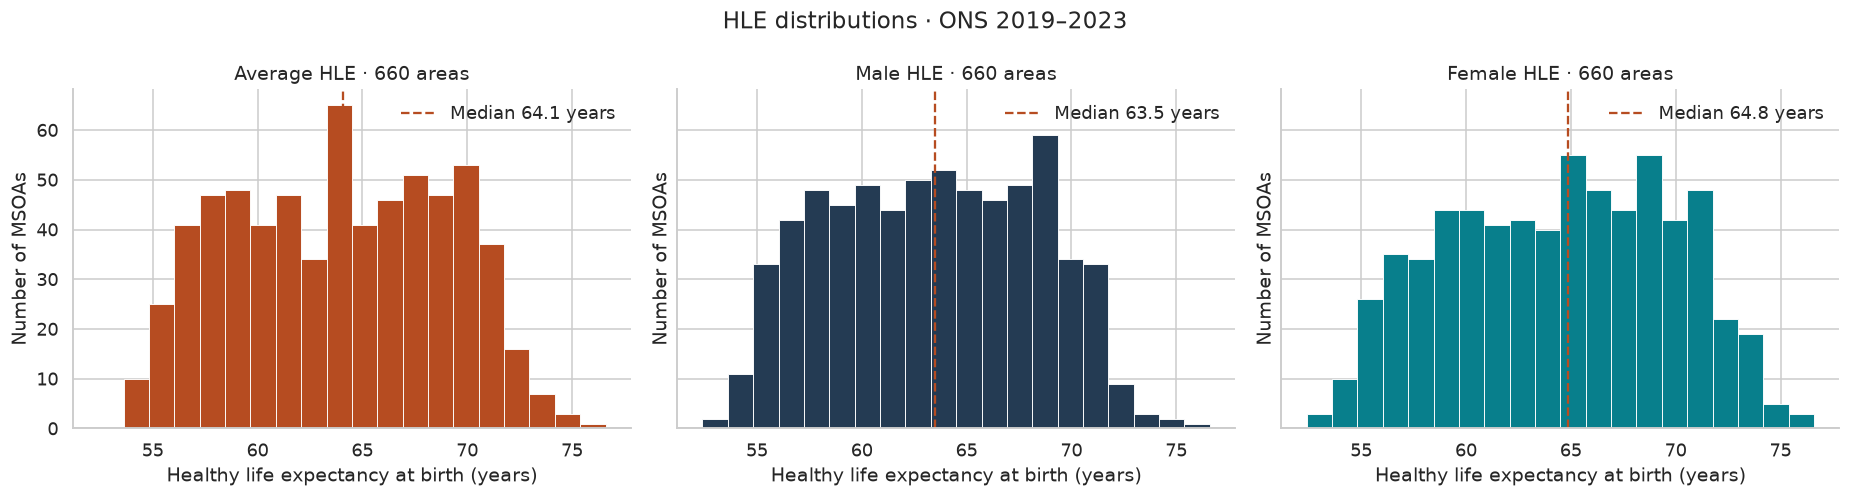

In [8]:
# One set of bin edges for all three panels, so their shapes can be compared directly.
bins = np.linspace(wide[hle_columns].min().min(), wide[hle_columns].max().max(), 21)

# sharex and sharey keep the three scales identical.
fig,axes = plt.subplots(1,3,figsize=(17,4.6),sharex=True,sharey=True)

for ax,column,colour,sex in zip(axes,hle_columns,["#b64c21","#243b53","#087f8c"],["Average","Male","Female"]):
    ax.hist(wide[column],bins=bins,color=colour,edgecolor="white",linewidth=.6)
    median = wide[column].median()
    ax.axvline(median,color="#b64c21",linestyle="--",label=f"Median {median:.1f} years")
    ax.set(title=f"{sex} HLE · 660 areas",xlabel="Healthy life expectancy at birth (years)",ylabel="Number of MSOAs")
    ax.legend(frameon=False)

fig.suptitle("HLE distributions · ONS 2019–2023",fontsize=15)
fig.tight_layout()
save_figure(fig,"01_hle_histograms.png")

## 9. HLE and contextual measures — second plot type

**Question:** which area measures have the strongest ranked links with HLE? I use pairwise Spearman correlations. Each crime comparison has **654** non-missing areas; other comparisons have **660**. No missing crime value is filled or turned into a zero. The core measures and ethnicity shares are displayed separately for readable labels; together they cover every prepared measure. Many comparisons are exploratory, so the largest coefficients are leads for review rather than confirmed discoveries.

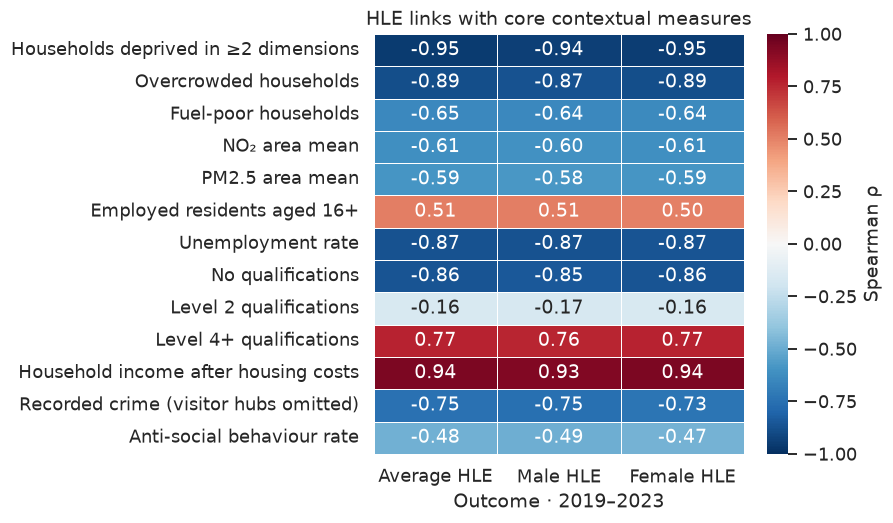

,hle_average,hle_male,hle_female
households_deprived_2plus_pct,-0.953,-0.944,-0.948
overcrowded_households_pct,-0.886,-0.870,-0.888
fuel_poor_households_pct,-0.646,-0.645,-0.638
no2_area_mean_ug_m3,-0.613,-0.604,-0.610
pm25_area_mean_ug_m3,-0.593,-0.581,-0.592
employed_residents_16plus_pct,0.509,0.509,0.501
unemployment_rate_active_pct,-0.874,-0.868,-0.866
no_qualifications_pct,-0.862,-0.847,-0.862
level2_qualifications_pct,-0.161,-0.166,-0.159
level4plus_pct,0.770,0.760,0.768


In [9]:
# Spearman rank correlation: it does not assume a straight-line relationship and is less affected by outliers than Pearson. Areas with a missing value are dropped pair by pair.
correlation = wide[hle_columns + analysis_measures].corr(method="spearman",min_periods=3)
hle_correlations = correlation.loc[analysis_measures,hle_columns]

# The number of areas behind each correlation. Crime has six fewer.
pair_counts = pd.DataFrame({h:[int(wide[[h,m]].dropna().shape[0]) for m in analysis_measures] for h in hle_columns},index=analysis_measures)

# Crime uses 654 areas (660 minus the six visitor hubs). Every other measure uses all 660.
assert pair_counts.loc["crime_for_analysis"].eq(654).all()
assert pair_counts.drop(index="crime_for_analysis").eq(660).all().all()
save_csv(hle_correlations,"hle_spearman_correlations.csv",index=True)
save_csv(pair_counts,"hle_correlation_pair_counts.csv",index=True)

# The 19 ethnic-group shares are shown on their own and are not part of the core set.
core_measures = [c for c in analysis_measures if c not in ethnicity_columns]


# Reusable heatmap: outcomes across, measures down. The colour scale is fixed from -1 to +1 so panels compare.
def heatmap_hle(columns,title,filename):
    plotted = hle_correlations.loc[columns].copy()
    plotted.index = [feature_info[c]["label"] for c in columns]
    plotted.columns = ["Average HLE","Male HLE","Female HLE"]
    fig,ax = plt.subplots(figsize=(8,max(4,len(columns)*.38)))
    sns.heatmap(plotted,vmin=-1,vmax=1,center=0,cmap="RdBu_r",annot=True,fmt=".2f",linewidths=.5,ax=ax,cbar_kws={"label":"Spearman ρ"})
    ax.set(title=title,xlabel="Outcome · 2019–2023",ylabel="")
    ax.tick_params(axis="y",rotation=0)
    fig.tight_layout()
    save_figure(fig,filename)


heatmap_hle(core_measures,"HLE links with core contextual measures","02_hle_context_heatmap.png")

display(hle_correlations.loc[core_measures].round(3))

### Ethnicity shares: exploratory relationships

Each column is a share of the same population, and the 19 shares sum to 100%. Raising one share necessarily changes others. These coefficients describe **area composition**, not the health of individuals in an ethnic group and not causal effects. I keep the detail and have not yet decided whether to group the shares or use them in modelling.

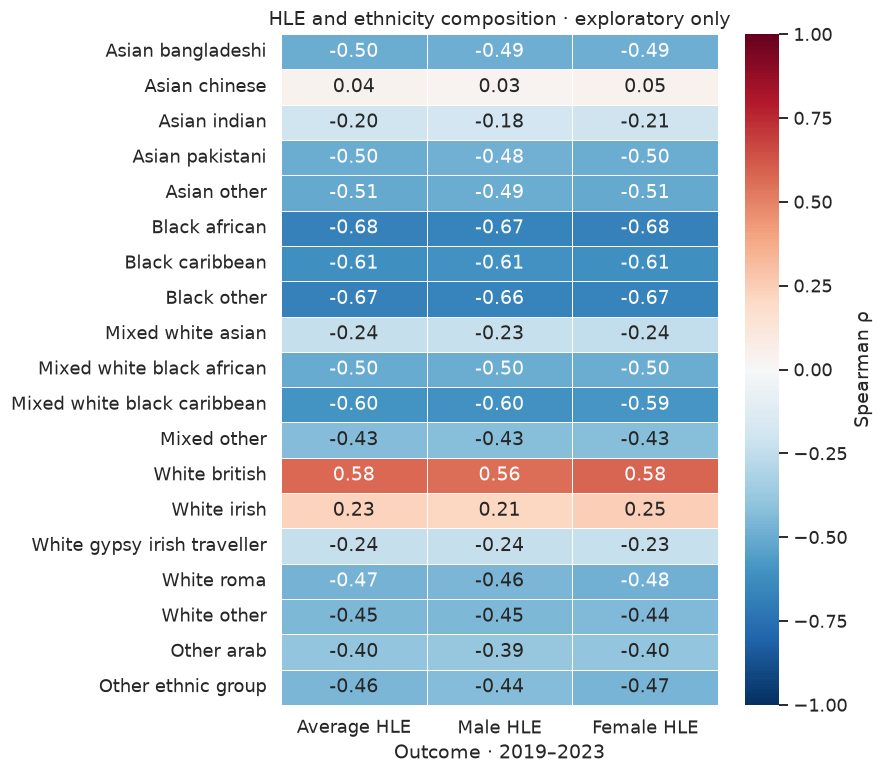

In [10]:
# Exploratory only: the 19 shares sum to 100% and overlap with deprivation, so this describes and does not select.
heatmap_hle(ethnicity_columns,"HLE and ethnicity composition · exploratory only","03_hle_ethnicity_heatmap.png")

### Scatter grid: one measure from each of three themes

I show income, NO₂ and crime against HLE for each sex. These are chosen to span three different themes (socioeconomic, environment, safety), not because they are the strongest. The strongest-link table is still saved to `strongest_relationships.csv`, but deprivation, overcrowding and income are one construct measured three ways, so plotting all three adds nothing. Each panel shows its pair count and coefficient. No regression line or significance claim is added.

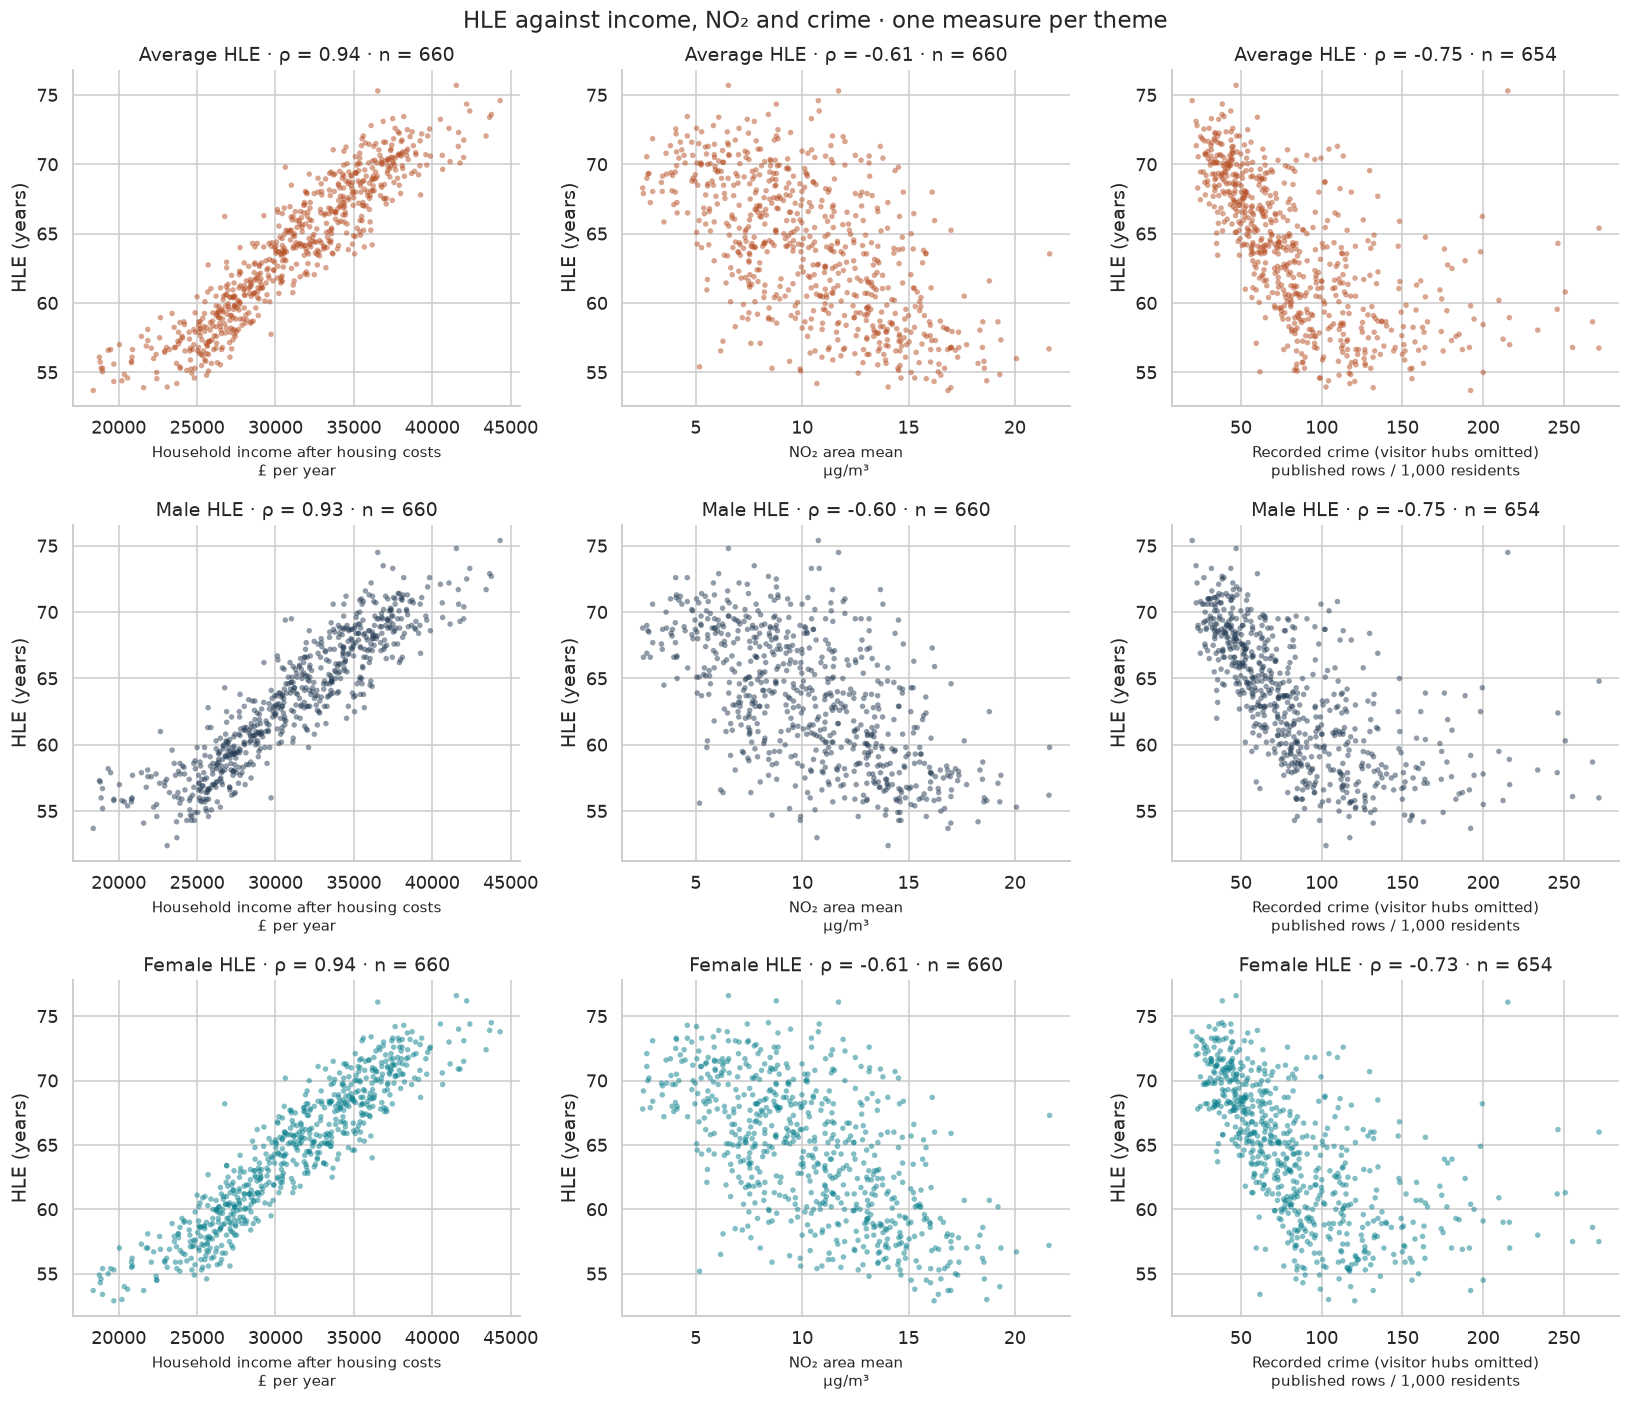

,outcome,measure,label,rho,n
0,hle_average,households_deprived_2plus_pct,Households deprived in ≥2 dimensions,-0.953,660
1,hle_average,annual_equivalised_income_after_housing_costs_gbp,Household income after housing costs,0.941,660
2,hle_average,overcrowded_households_pct,Overcrowded households,-0.886,660
3,hle_male,households_deprived_2plus_pct,Households deprived in ≥2 dimensions,-0.944,660
4,hle_male,annual_equivalised_income_after_housing_costs_gbp,Household income after housing costs,0.929,660
5,hle_male,overcrowded_households_pct,Overcrowded households,-0.870,660
6,hle_female,households_deprived_2plus_pct,Households deprived in ≥2 dimensions,-0.948,660
7,hle_female,annual_equivalised_income_after_housing_costs_gbp,Household income after housing costs,0.938,660
8,hle_female,overcrowded_households_pct,Overcrowded households,-0.888,660


In [11]:
# The three strongest correlations, by absolute value, for each outcome.
strongest = []

for h in hle_columns:
    for m in hle_correlations[h].abs().nlargest(3).index:
        strongest.append({"outcome":h,"measure":m,"label":feature_info[m]["label"],"rho":float(hle_correlations.loc[m,h]),"n":int(wide[[h,m]].dropna().shape[0])})

# One measure per theme keeps the grid readable: income, NO₂ and crime.
scatter_measures = ["annual_equivalised_income_after_housing_costs_gbp","no2_area_mean_ug_m3","crime_for_analysis"]
fig,axes = plt.subplots(3,3,figsize=(15,13))

for row,h in enumerate(hle_columns):
    for col,m in enumerate(scatter_measures):
        # Drop areas with a missing value for this pair only. For crime that removes the six visitor hubs.
        points = wide[[h,m]].dropna()
        rho = float(hle_correlations.loc[m,h])
        ax = axes[row,col]
        ax.scatter(points[m],points[h],s=13,alpha=.5,color=["#b64c21","#243b53","#087f8c"][row],edgecolors="none")
        ax.set_title(f"{['Average','Male','Female'][row]} HLE · ρ = {rho:.2f} · n = {len(points)}")
        ax.set_xlabel(feature_info[m]["label"] + "\n" + feature_info[m]["unit"],fontsize=10)
        ax.set_ylabel("HLE (years)")

fig.suptitle("HLE against income, NO₂ and crime · one measure per theme",fontsize=15)
fig.tight_layout()
save_figure(fig,"04_scatter_grid_by_theme.png")
strongest_table = pd.DataFrame(strongest)
save_csv(strongest_table,"strongest_relationships.csv")

display(strongest_table.round(3))

## 10. Theme overlap

**Question:** are different columns describing much the same area pattern? First I compare deprivation, income and the three qualification measures, then NO₂ and PM2.5. Then I compare **every core measure with every other**, because overcrowding, unemployment, qualifications, income and deprivation may all be one pattern measured several ways. Redundant measures can dominate later clustering and regression. A high correlation is a reason to simplify or compare alternatives, not proof that definitions are interchangeable. Ethnicity shares are left out of this comparison because they are a separate, undecided question.

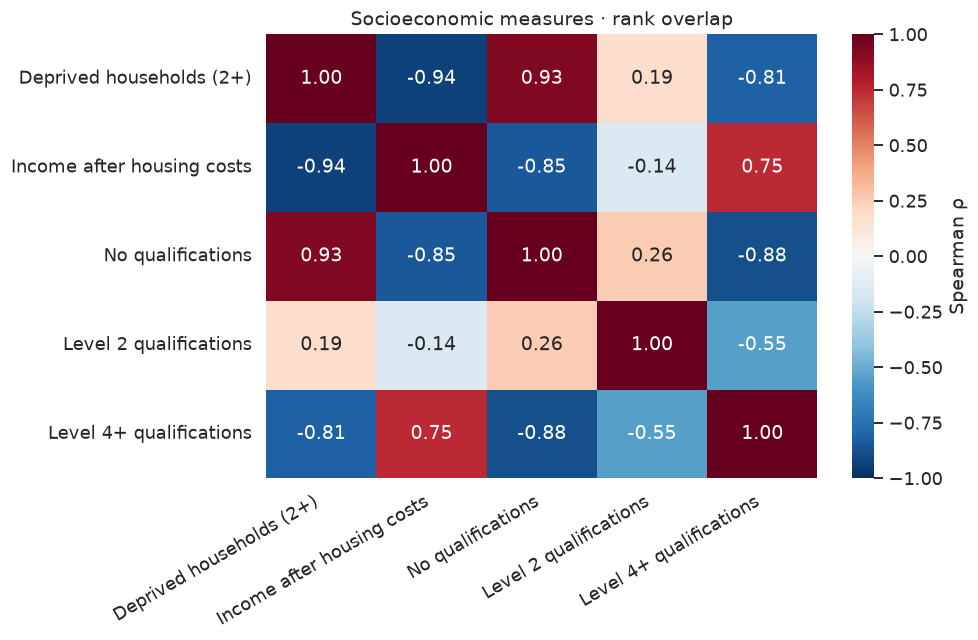

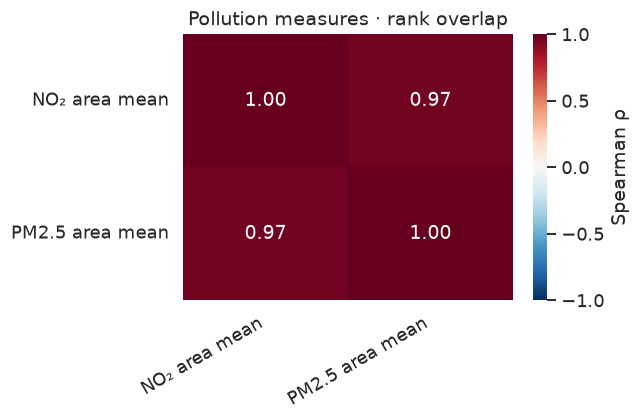

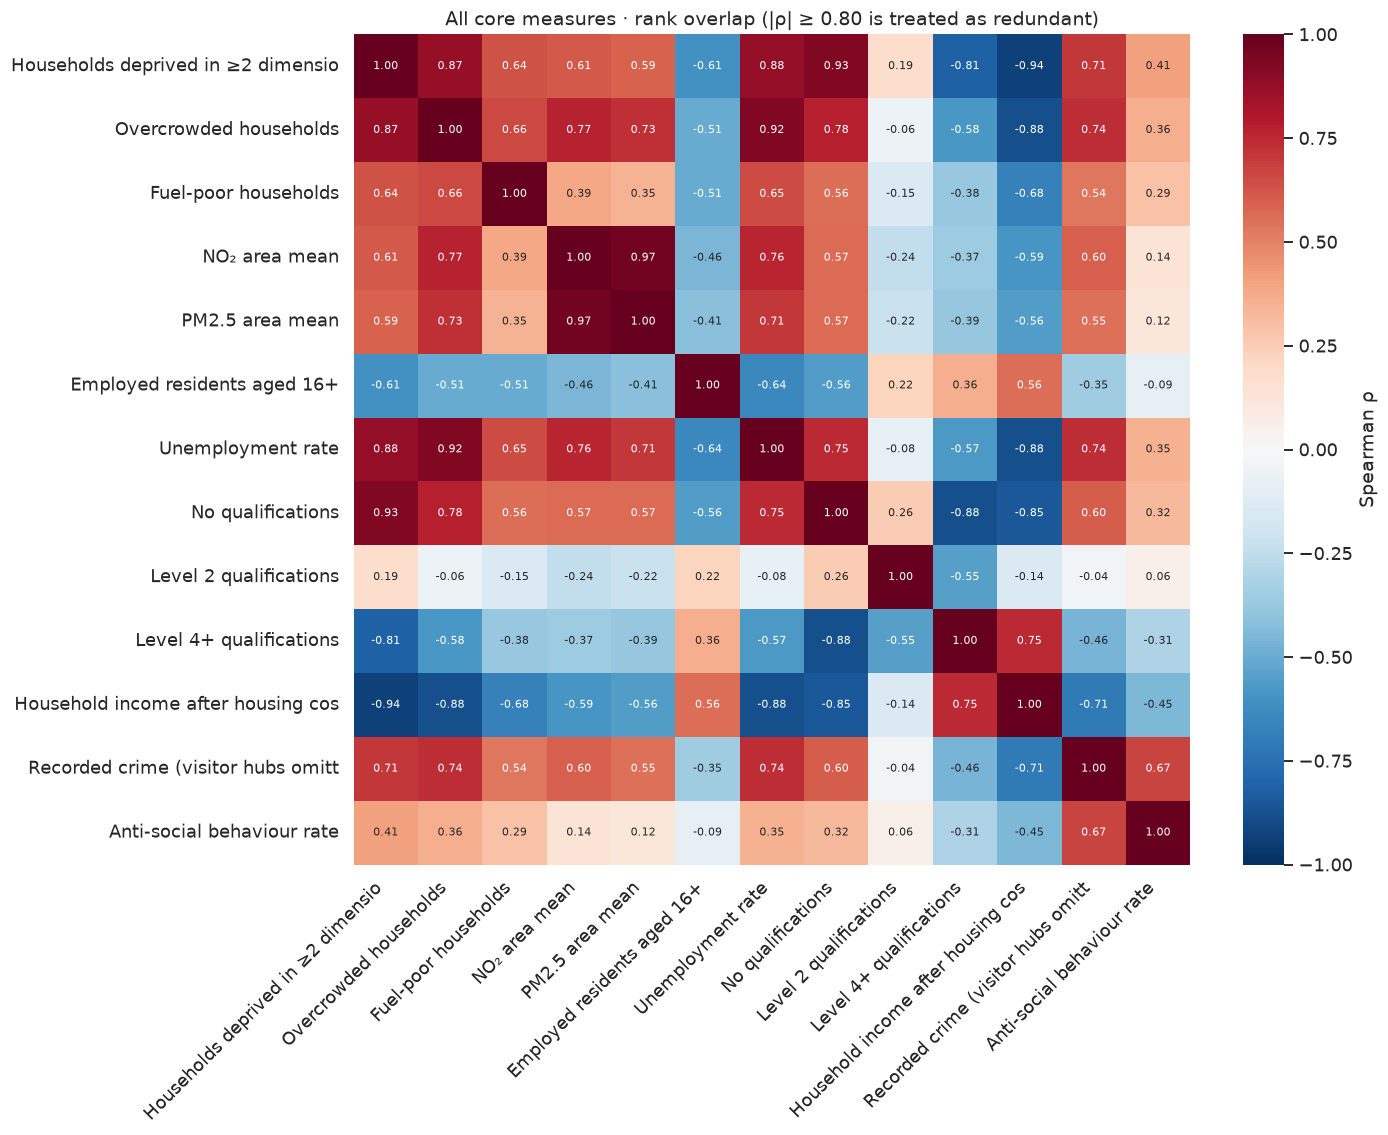

,measure_a,measure_b,rho
0,households_deprived_2plus_pct,overcrowded_households_pct,0.872
1,households_deprived_2plus_pct,unemployment_rate_active_pct,0.876
2,households_deprived_2plus_pct,no_qualifications_pct,0.927
3,households_deprived_2plus_pct,level4plus_pct,-0.813
4,households_deprived_2plus_pct,annual_equivalised_income_after_housing_costs_gbp,-0.937
5,overcrowded_households_pct,unemployment_rate_active_pct,0.924
6,overcrowded_households_pct,annual_equivalised_income_after_housing_costs_gbp,-0.876
7,no2_area_mean_ug_m3,pm25_area_mean_ug_m3,0.968
8,unemployment_rate_active_pct,annual_equivalised_income_after_housing_costs_gbp,-0.877
9,no_qualifications_pct,level4plus_pct,-0.878


In [12]:
# Overlap is shown within the two themes that have several similar measures.
themes = {"Socioeconomic":["households_deprived_2plus_pct","annual_equivalised_income_after_housing_costs_gbp","no_qualifications_pct","level2_qualifications_pct","level4plus_pct"],
          "Pollution":["no2_area_mean_ug_m3","pm25_area_mean_ug_m3"]}
overlap_matrices = {}

for theme,columns in themes.items():
    overlap = wide[columns].corr(method="spearman")
    overlap_matrices[theme] = overlap
    save_csv(overlap,theme.lower()+"_overlap.csv",index=True)

    # Shorter labels, so the long names fit on the axes.
    labels = {c:feature_info[c]["label"].replace("Household income after housing costs","Income after housing costs").replace("Households deprived in ≥2 dimensions","Deprived households (2+)") for c in columns}
    fig,ax = plt.subplots(figsize=(9,6) if len(columns)>2 else (6,4))
    sns.heatmap(overlap.rename(index=labels,columns=labels),vmin=-1,vmax=1,center=0,cmap="RdBu_r",annot=True,fmt=".2f",ax=ax,cbar_kws={"label":"Spearman ρ"})
    ax.set_title(theme+" measures · rank overlap")
    ax.tick_params(axis="x",rotation=30)

    for tick in ax.get_xticklabels():tick.set_ha("right")

    ax.tick_params(axis="y",rotation=0)
    fig.tight_layout()
    save_figure(fig,"05_"+theme.lower()+"_overlap.png")

# Rank correlation between every pair of core measures, to find the redundant ones.
core_overlap = wide[core_measures].corr(method="spearman")
save_csv(core_overlap,"core_overlap.csv",index=True)

# Pairs with |rho| of 0.80 or more are treated as redundant. This is a working guide, not a significance test.
high_pairs = [{"measure_a":a,"measure_b":b,"rho":float(core_overlap.loc[a,b])}
              for i,a in enumerate(core_measures) for b in core_measures[i+1:] if abs(core_overlap.loc[a,b])>=.80]
save_csv(pd.DataFrame(high_pairs).sort_values("rho",key=abs,ascending=False),"high_overlap_pairs.csv")

# Labels cut to 34 characters so they fit on the full heatmap.
short = {c:feature_info[c]["label"][:34] for c in core_measures}
fig,ax = plt.subplots(figsize=(13,10.5))
sns.heatmap(core_overlap.rename(index=short,columns=short),vmin=-1,vmax=1,center=0,cmap="RdBu_r",annot=True,fmt=".2f",annot_kws={"size":7},ax=ax,cbar_kws={"label":"Spearman ρ"})
ax.set_title("All core measures · rank overlap (|ρ| ≥ 0.80 is treated as redundant)")
ax.tick_params(axis="x",rotation=45)

for tick in ax.get_xticklabels():tick.set_ha("right")

fig.tight_layout()
save_figure(fig,"05_core_overlap.png")

display(pd.DataFrame(high_pairs).round(3))


### Provisional representatives

I keep every source measure in the wide table. For a provisional regression shortlist I start from **household income after housing costs** as the socioeconomic anchor. It has no health component, so it cannot partly restate the outcome. Remaining core measures are then considered in order of their average absolute link with the two HLE outcomes, and any measure with absolute Spearman correlation **at least 0.80** with one already chosen is marked an alternative. The 0.80 value is an exploratory redundancy guide, not a significance threshold, and does not alter either saved flag rule.

Two measures are set aside by judgement before the rule runs. **Households deprived in ≥2 dimensions** has the strongest HLE link, but one of its four dimensions is health and disability, so it overlaps the outcome. It stays in the table for description and is excluded from regression. **Level 2 qualifications** is the middle band; only the extremes (no qualifications, level 4+) carry a signal (ρ ≈ −0.17), so it is not shortlisted.

The shortlist uses these same data and is therefore exploratory. It needs later validation. I have not yet decided how to treat ethnicity.

In [13]:
# Average strength of each measure's link with the three outcomes. It ranks the candidates.
strength = hle_correlations.abs().mean(axis=1)

# Income after housing costs is the socioeconomic anchor and is chosen first.
anchor = "annual_equivalised_income_after_housing_costs_gbp"

# Two measures set aside, with the reason kept for the output table.
outcome_overlap = {"households_deprived_2plus_pct":"Includes a health/disability dimension that overlaps HLE; keep for description, exclude from regression"}
weak_measure = {"level2_qualifications_pct":"Middle qualification band with very weak HLE link (rho about -0.17); not shortlisted"}

# Theme of each core measure. The assert after it stops the notebook if a measure has no theme.
theme_of = {"annual_equivalised_income_after_housing_costs_gbp":"Socioeconomic","households_deprived_2plus_pct":"Socioeconomic",
    "overcrowded_households_pct":"Housing","fuel_poor_households_pct":"Housing",
    "no2_area_mean_ug_m3":"Environment","pm25_area_mean_ug_m3":"Environment",
    "employed_residents_16plus_pct":"Labour market","unemployment_rate_active_pct":"Labour market",
    "no_qualifications_pct":"Education","level2_qualifications_pct":"Education","level4plus_pct":"Education",
    "crime_for_analysis":"Safety","asb_rows_per_1000_residents":"Safety"}
assert set(theme_of)==set(core_measures), set(core_measures)^set(theme_of)

# Everything except the anchor and the two set-aside measures.
candidates = [m for m in core_measures if m not in outcome_overlap and m not in weak_measure and m != anchor]

# Greedy selection: the anchor first, then the rest from strongest to weakest link with HLE.
order = [anchor] + sorted(candidates,key=lambda c:strength[c],reverse=True)
selected, representatives = [], []

# A measure becomes a provisional representative only if it overlaps (|rho| of 0.80 or more) with none already chosen. Otherwise it is kept as an alternative.
for m in order:
    duplicates = [o for o in selected if abs(core_overlap.loc[m,o])>=.80]

    if duplicates:
        decision = "Alternative"
        reason = "High overlap with " + ", ".join(f"{feature_info[d]['label']} (rho {core_overlap.loc[m,d]:.2f})" for d in duplicates)
    else:
        decision = "Provisional representative"
        reason = "Socioeconomic anchor; no health component" if m==anchor else "Not redundant with any already chosen measure (all |rho| < 0.80)"
        selected.append(m)

    representatives.append({"theme":theme_of[m],"measure":m,"label":feature_info[m]["label"],"decision":decision,"reason":reason})

# Add the set-aside measures, so every core measure appears once in the table.
for m,reason in {**outcome_overlap,**weak_measure}.items():
    representatives.append({"theme":theme_of[m],"measure":m,"label":feature_info[m]["label"],"decision":"Excluded from regression" if m in outcome_overlap else "Not shortlisted","reason":reason})

representative_table = pd.DataFrame(representatives)
save_csv(representative_table,"theme_representatives_for_review.csv")

display(representative_table[["theme","label","decision","reason"]])

,theme,label,decision,reason
0,Socioeconomic,Household income after housing costs,Provisional representative,Socioeconomic anchor; no health component
1,Housing,Overcrowded households,Alternative,High overlap with Household income after housi...
2,Labour market,Unemployment rate,Alternative,High overlap with Household income after housi...
3,Education,No qualifications,Alternative,High overlap with Household income after housi...
4,Education,Level 4+ qualifications,Provisional representative,Not redundant with any already chosen measure ...
5,Safety,Recorded crime (visitor hubs omitted),Provisional representative,Not redundant with any already chosen measure ...
6,Housing,Fuel-poor households,Provisional representative,Not redundant with any already chosen measure ...
7,Environment,NO₂ area mean,Provisional representative,Not redundant with any already chosen measure ...
8,Environment,PM2.5 area mean,Alternative,High overlap with NO₂ area mean (rho 0.97)
9,Labour market,Employed residents aged 16+,Provisional representative,Not redundant with any already chosen measure ...


## 11. Save the results

I save the calculated results used by the closing interpretation.

In [14]:
# Headline numbers from this notebook, saved as JSON so they can be read back rather than retyped.
summary = {"rows":len(wide),"columns":len(wide.columns),"measure_count":len(analysis_measures),
    "student_areas":int(wide.student_dominated.sum()),"visitor_hubs":int(wide.visitor_hub.sum()),
    "missing_cells":int(wide.isna().sum().sum()),"output_run":output_folder.relative_to(project_folder).as_posix(),
    "hle_statistics":{h:{k:float(statistics.loc[h,k]) for k in ["mean","median","std","var","min","max"]} for h in hle_columns},
    "interval_median":{sex:float(interval_summary.loc[sex,"median"]) for sex in ["Average","Male","Female"]},
    "strongest":strongest,"pollution_overlap":float(overlap_matrices["Pollution"].iloc[0,1]),
    "representatives":representatives}

with (output_folder / "results_summary.json").open("w") as stream:json.dump(summary,stream,indent=2)

print("Wide table, dictionary, audit, statistics, correlations and figures saved.")

Wide table, dictionary, audit, statistics, correlations and figures saved.


## 12. What the data shows, and its limits

The 660 areas span 53.7–75.7 years of average HLE, 52.4–75.4 years of male HLE and 52.9–76.6 years of female HLE. Their means are 63.89, 63.36 and 64.41 years; standard deviations are 5.06, 4.90 and 5.31 years. These are spreads between area estimates, not the uncertainty of each estimate.

- The strongest observed link with average HLE is **Households deprived in ≥2 dimensions**, Spearman ρ = **-0.953**, with household income after housing costs next at **0.941**. This is a ranked association selected after looking at many measures.
- The strongest observed male link is **Households deprived in ≥2 dimensions**, Spearman ρ = **-0.944**, using 660 areas. This is a ranked association selected after looking at many measures.
- The strongest observed female link is **Households deprived in ≥2 dimensions**, Spearman ρ = **-0.948**, using 660 areas. This is a ranked association selected after looking at many measures.

NO₂ and PM2.5 have Spearman ρ = **0.968**. The overlap table and provisional representatives explain the proposed simplification. I have not yet decided how to treat ethnicity.

The median full 95% HLE interval width is **3.0 years for men** and **2.8 for women**. The approximate interval for the average is narrower, **2.1 years**, because it combines two estimates, and it assumes independent errors, so it is probably too narrow. Separate interval overlap alone does not test whether a difference is significant.

### Limits that travel with the results

- **Period mismatch:** 2024 context follows the pooled 2019–2023 HLE period. It cannot be assumed to explain earlier health outcomes.
- **Neighbouring areas are related:** spatial dependence affects later tests and model validation. No independent-area p-values are claimed here.
- **Area-level evidence:** these measures describe areas, not individuals. Use “linked with”, not “causes”.
- **Crime is provisional:** published rows and repeated IDs require care; resident denominators can exaggerate visitor-hub rates. The six hubs are blank only in `crime_for_analysis`. ASB remains unchanged and has its own footfall caveat.
- **Imputation and modelling:** source flags and uncertainty are retained; household deprivation includes a health/disability dimension that overlaps HLE, so it stays descriptive and is excluded from the regression shortlist.
- **Selection and composition:** strongest scatter plots and theme choices are exploratory; ethnicity percentages are interdependent. They are not an independently validated predictor set.